## README:

* Cells labeled with '## ----- CONFIG ----- ##' contain parameters that need to be set manually

In [1]:
# NOTE: UNCOMMENT ALL LINES AND RUN CELL IF RUNNING NOTEBOOK ON GOOGLE COLAB
!pip install dotenv
!pip install FinRL
!pip install stable_baselines3 sb3_contrib --upgrade
!pip install alpaca_trade_api
!pip install exchange_calendars
!pip install stockstats
!pip install wrds
!pip install websockets
!pip install yfinance
!pip install ta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.2/127.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 17.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 23.2 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.3-cp312-cp312-linux_x86_64.whl size=15688 sha256=de4d0877ceacdaad75826344308d32a936757a2d3ee2ff1a556b6294d00a8ced
  Stored in directory: /root/.cache/pip/wheels/ba/bd/3f/f043e8f634db9c90ae128d631f43ae9990eef01274a63291f9
  

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.5/182.5 kB 20.1 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 10.4
    Uninstalling websockets-10.4:
      Successfully uninstalled websockets-10.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
alpaca-trade-api 3.2.0 requires websockets<11,>=9.0, but you have websockets 15.0.1 which is incompatible.
google-adk 1.14.1 requires PyYAML<7.0.0,>=6.0.2, but you have pyyaml 6.0.1 which is incompatible.
  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=f27df53674944eb7ece17e799629b83adc203fb9d3947bbe09288d38765c233b
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [1]:
import os
import sys

# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

In [2]:
# NOTE: UNCOMMENT ALL LINES AND RUN CELL IF RUNNING NOTEBOOK ON GOOGLE COLAB
import os
import sys
from google.colab import drive

drive.mount('/content/drive')

# NOTE: CHANGE PATH AS NECESSARY
PATH = '/content/drive/MyDrive/ELEN6885 Final Project'
sys.path.append(os.path.join(PATH, 'rl-trading'))
os.makedirs(os.path.join(PATH, 'data'), exist_ok=True)
os.makedirs(os.path.join(PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(PATH, 'tensorboard_logs'), exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from gymnasium import spaces
from finrl.meta.preprocessor.preprocessors import data_split
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

from trading_environment.custom_env import StockTradingEnv
from trading_environment import rewards
from experiments.normalization import MaskedVecNormalize
from experiments.early_stopping import MultiCondEarlyStop
from evaluation.backtest import run_backtest
from evaluation.visualize import plot_trades_on_price_from_backtest
from evaluation import financial_metrics
from evaluation.get_policy_distributions import get_policy_distributions
from evaluation.plot_policy_comparison import plot_policy_comparison
from evaluation.plot_stock_distribution import plot_stock_distribution

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
%matplotlib

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [4]:
if not torch.cuda.is_available():
  raise Exception('Please use a GPU compute')

## Load env variables

In [5]:
load_dotenv(r'../.env')

try:
  DATA_DIR = os.getenv('DATA_DIR', os.path.join(PATH, 'data'))
except:
  DATA_DIR = None
print(DATA_DIR)

/content/drive/MyDrive/ELEN6885 Final Project/data


In [6]:
# record experiment start dt
import datetime

EXP_START_DT = datetime.datetime.now().strftime('%Y%m%d_%H%M')
EXP_START_DT

'20251215_0210'

## MLP Feature Extractor

In [7]:
class SimpleMLP(nn.Module):
    def __init__(
        self, input_dim: int, hidden_dim: int = 64, output_dim: int = 1
    ):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: [batch_size, input_dim]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.out(x)
        return x

In [8]:
class MLPFeaturesExtractor(BaseFeaturesExtractor):
    """
    Wrap SimpleMLP as a feature extractor.
    """
    def __init__(
        self, observation_space: spaces.Box, features_dim: int = 64
    ):
        super().__init__(observation_space, features_dim)

        # shape: (window_size, feature_dim)
        # will only use the latest (current) state, ignore lagged states
        input_dim = observation_space.shape[1]

        self.mlp = SimpleMLP(
            input_dim=input_dim,
            hidden_dim=features_dim,
            output_dim=features_dim
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        # observations: [batch_size, 100, 71]
        # batch_size = n_envs in VecEnv
        x = observations[:, -1, :] # get current state
        return self.mlp(x)

## Train-test split and normalization

In [9]:
## ----- CONFIG ----- ##
SPLIT_DATE = '2018-01-01' # format %Y-%m-%d
DATA_FILE_NAME = 'data_with_features.csv'

base_columns = [
    'date',	'tic', 'close',	'high',	'low', 'open', 'volume'
]

stock_features = [
    'atr_30',
    'macd',
    'macd_hist',
    'rsi_30'
]

economy_features = [
    'CPIAUCSL',
    'DFF',
    'ICSA',
    'T10Y2Y',
    'USEPUINDXD',
    'VIXCLS',
    # 'doy_sin',
    # 'doy_cos',
    'dow_sin',
    'dow_cos'
]

In [10]:
# load finalized data
data_df = pd.read_csv(os.path.join(DATA_DIR, DATA_FILE_NAME))

data_df = data_df[base_columns + stock_features + economy_features]
stock_names = data_df['tic'].unique()
data_df['date'] = pd.to_datetime(data_df['date'], format='%Y-%m-%d')
data_df.shape

(67300, 19)

In [11]:
SPLIT_DATE = pd.to_datetime(SPLIT_DATE, format='%Y-%m-%d')

# train-test split
min_date = data_df['date'].min()
max_date = data_df['date'].max()
print(min_date, max_date)

train_df = data_split(data_df, start=min_date, end=SPLIT_DATE)
trade_df = data_split(data_df, start=SPLIT_DATE, end=max_date + pd.Timedelta(days=1))

print(train_df.shape, trade_df.shape)
print(train_df['date'].min(), train_df['date'].max())
print(trade_df['date'].min(), trade_df['date'].max())
print('Any missing values in training:', train_df.isna().any().any())
print('Any missing values in testing:', trade_df.isna().any().any())

1999-03-11 00:00:00 2025-12-09 00:00:00
(47340, 19) (19960, 19)
1999-03-11 00:00:00 2017-12-29 00:00:00
2018-01-02 00:00:00 2025-12-09 00:00:00
Any missing values in training: False
Any missing values in testing: False


## Environment configuration

In [12]:
## ----- CONFIG ----- ##
price = 'close'         # name of price to use for transactions / rewards
hmax = 1000             # maximum number of stocks to transact at each step
initial_amount = 5000   # initial amount of cash
buy_cost_pct = 0.005    # % cost of each stock purchase
sell_cost_pct = 0.005   # % cost of each stock sale
num_stock_shares = 0    # number of starting shares
window_size = 50        # number of previous time steps to encode
# reward_func = rewards.PnLReward()
reward_func = rewards.PenalizedTurnover(penalty=5e-3)
reward_scaling = 1      # reward scaling

In [13]:
# environment kwargs
stock_dim = len(data_df['tic'].unique())
state_space = 1 + 2 * stock_dim + len(stock_features) * stock_dim + len(economy_features)

env_kwargs = {
    "price": price,
    "hmax": hmax,
    "initial_amount": initial_amount,
    "buy_cost_pct": [buy_cost_pct] * stock_dim,
    "sell_cost_pct": [sell_cost_pct] * stock_dim,
    "stock_dim": stock_dim,
    "state_space": state_space,
    "action_space": stock_dim,
    "reward_function": reward_func,
    "reward_scaling": 1,
    "num_stock_shares": [num_stock_shares] * stock_dim,
    "price": "close",
    "stock_features": stock_features,
    "economy_features": economy_features,
    "window_size": window_size
}


## Data normalization

In [14]:
## ----- CONFIG ----- ##
PARALLEL_RUNS = 10

In [15]:
# do not normalize prices, since they are used to compute rewards
# feature index starts after cash + prices * stock_dim + shares * stock_dim
feature_start_idx = 1 + 2 * stock_dim

In [16]:
def make_train_env():
    env = StockTradingEnv(df=train_df, **env_kwargs)
    env = Monitor(env, filename=f"training_monitor_{EXP_START_DT}", allow_early_resets=True)
    return env

def make_valid_env():
    env = StockTradingEnv(df=trade_df, **env_kwargs)
    env = Monitor(env, filename=f"trading_monitor_{EXP_START_DT}", allow_early_resets=True)
    return env

In [17]:
train_vec_env = DummyVecEnv([make_train_env for _ in range(PARALLEL_RUNS)])

obs_shape = train_vec_env.observation_space.shape   # (window_size, feature_dim)

# features_to_normalize = list of indices along the *feature_dim* axis
normalize_mask = np.zeros(obs_shape, dtype=bool)
# broadcast those feature indices over all time steps
normalize_mask[:, feature_start_idx:] = True

# Wrap training env with MaskedVecNormalize (this FITS the stats)
train_norm_env = MaskedVecNormalize(
    train_vec_env,
    normalize_mask=normalize_mask.any(axis=0),
    norm_obs=True,
    norm_reward=False,
    clip_obs=10.0,
    training=True
)

In [18]:
## ----- CONFIG ----- ##
policy_kwargs = dict(
    net_arch=[64, 64],
    lstm_hidden_size=32,
    n_lstm_layers=3,
    shared_lstm=False,
    enable_critic_lstm=True,
    features_extractor_class=MLPFeaturesExtractor,
    features_extractor_kwargs=dict(features_dim=64),
)

model = RecurrentPPO(
    policy="MlpLstmPolicy",
    env=train_norm_env,

    # --- PPO rollout & update ---
    n_steps=64,
    batch_size=32,
    n_epochs=5,
    gamma=0.99,
    gae_lambda=0.95,

    # --- Optimization ---
    learning_rate=3e-4,
    max_grad_norm=0.5,
    clip_range=0.15,
    vf_coef=0.5,
    ent_coef=0.10,

    # --- Misc ---
    verbose=0,
    tensorboard_log=os.path.join(PATH, 'tensorboard_logs'),
    policy_kwargs=policy_kwargs,
)

###Load Model

In [19]:
from stable_baselines3 import PPO

model = PPO.load(
    '/content/drive/MyDrive/ELEN6885 Final Project/models/RecurrentPPO_20251214_2343.zip'
)

## Quick evaluation

In [20]:
valid_vec_env = DummyVecEnv([make_valid_env])

# New MaskedVecNormalize for validation, SAME MASK, but NO updating
valid_norm_env = MaskedVecNormalize(
    valid_vec_env,
    normalize_mask=normalize_mask.any(axis=0),
    norm_obs=True,
    norm_reward=False,
    clip_obs=10.0,
    training=False
)

# Copy fitted stats from training to validation
valid_norm_env.obs_rms = train_norm_env.obs_rms
valid_norm_env.training = False
valid_norm_env.norm_reward = False

In [21]:
# do not randomize starting_step
valid_env_kwargs = {**env_kwargs, 'starting_step': 0}

res = run_backtest(
    model,
    valid_norm_env,
    valid_env_kwargs
)
res.shape

/content/drive/MyDrive/ELEN6885 Final Project/rl-trading/evaluation/backtest.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.0108826057985425, -0.0035326224751770496, -0.015396922826766968, -0.0003424643073230982, -0.02291511744260788, -0.014230476692318916, -0.023429328575730324, 0.04637954756617546, -0.025975357741117477, -0.011110789142549038, 0.007778708823025227, -0.006578128784894943, 0.010207075625658035, 0.0189417265355587, 0.006910459604114294, -0.02591143734753132, 0.009869311936199665, 0.018642811104655266, -0.004686076194047928, 0.009810138493776321, 0.003382541937753558, 0.006218716502189636, 0.01367036160081625, -0.0022468764800578356, -0.028749490156769753, -0.04183509945869446, -0.0029007229022681713, -0.014017297886312008, 0.004348063841462135, 0.0034770802594721317, -0.011636963114142418, 0.017950061708688736, 0.022970514371991158, 0.04322695732116699, 0.0018107148353010416, 0.

(1995, 22)

In [22]:
financial_metrics.net_asset_change(res)

np.float64(23165.95134473484)

## Policy Analysis

In [23]:
mean_base, std_base, mean_high, std_high, avg_vix, high_vix = get_policy_distributions(
    model=model,
    valid_norm_env=valid_norm_env,
    train_df=train_df,
    vix_idx=66
)

sorted_tickers = sorted(train_df['tic'].unique())

diff = np.abs(mean_base - mean_high).max()

print(f"Raw Baseline VIX: {avg_vix:.2f}")
print(f"Raw High VIX:     {high_vix:.2f}")
print(f"\nMax Action Difference: {diff:.6f}")

print("\n--- Baseline Means ---")
print(mean_base)
print("\n--- High VIX Means ---")
print(mean_high)

Raw Baseline VIX: 20.03
Raw High VIX:     32.92

Max Action Difference: 0.000000

--- Baseline Means ---
[  7.2005835 564.08386    16.11519     7.8635    -15.21994     9.055601
  -5.1624174  17.523655    9.111921   -2.5822198]

--- High VIX Means ---
[  7.2005835 564.08386    16.11519     7.8635    -15.21994     9.055601
  -5.1624174  17.523655    9.111921   -2.5822198]


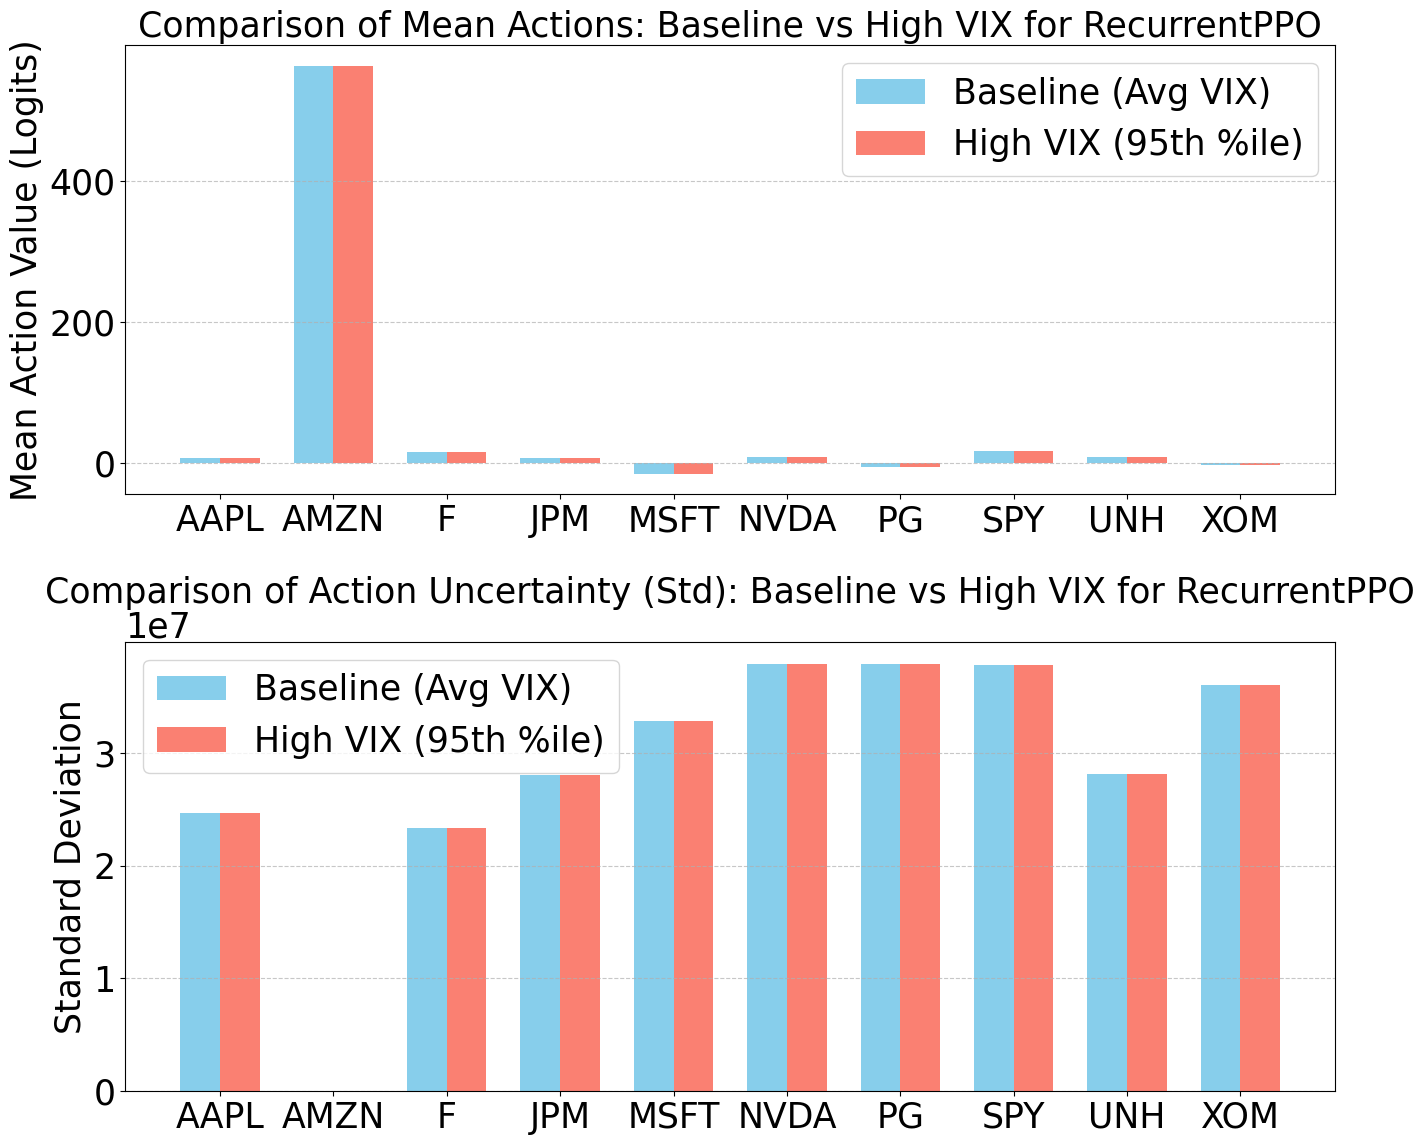

In [49]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Set global font sizes for labels and titles
plt.rcParams.update({
    'font.size': 25,          # default font size
    'axes.titlesize': 25,     # font size for titles
    'axes.labelsize': 25,     # font size for x and y labels
    'xtick.labelsize': 25,    # font size for x-axis tick labels
    'ytick.labelsize': 25,    # font size for y-axis tick labels
    'legend.fontsize': 25,    # font size for legend
})


# Ensure stock names are available
if 'sorted_tickers' not in locals():
    sorted_tickers = sorted(train_df['tic'].unique())

# Call the function with the variables expected to be in the global scope
plot_policy_comparison(sorted_tickers, mean_base, mean_high, std_base, std_high, model_name='RecurrentPPO')



--- Stock: AAPL ---
Baseline: Mean=7.200583457946777, Std=24694496.0
High VIX: Mean=7.200583457946777, Std=24694496.0
Shift: 0.0


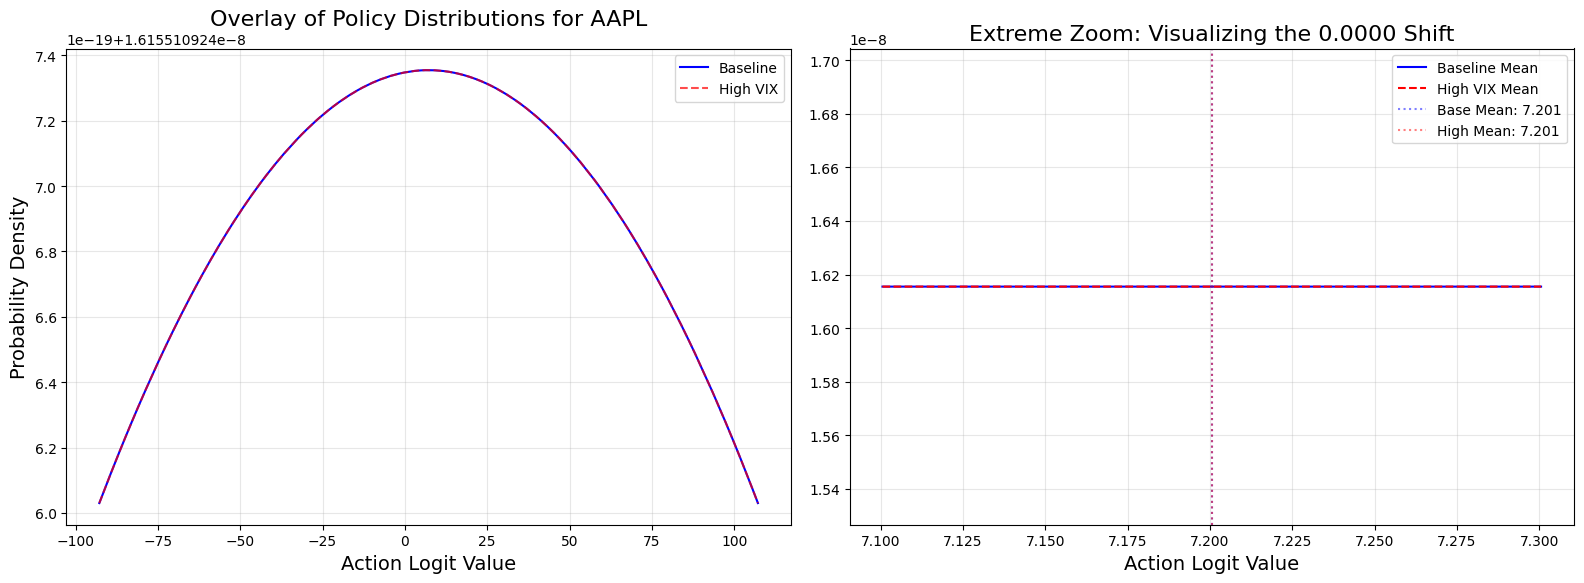


--- Stock: AMZN ---
Baseline: Mean=564.0838623046875, Std=451.1393737792969
High VIX: Mean=564.0838623046875, Std=451.1393737792969
Shift: 0.0


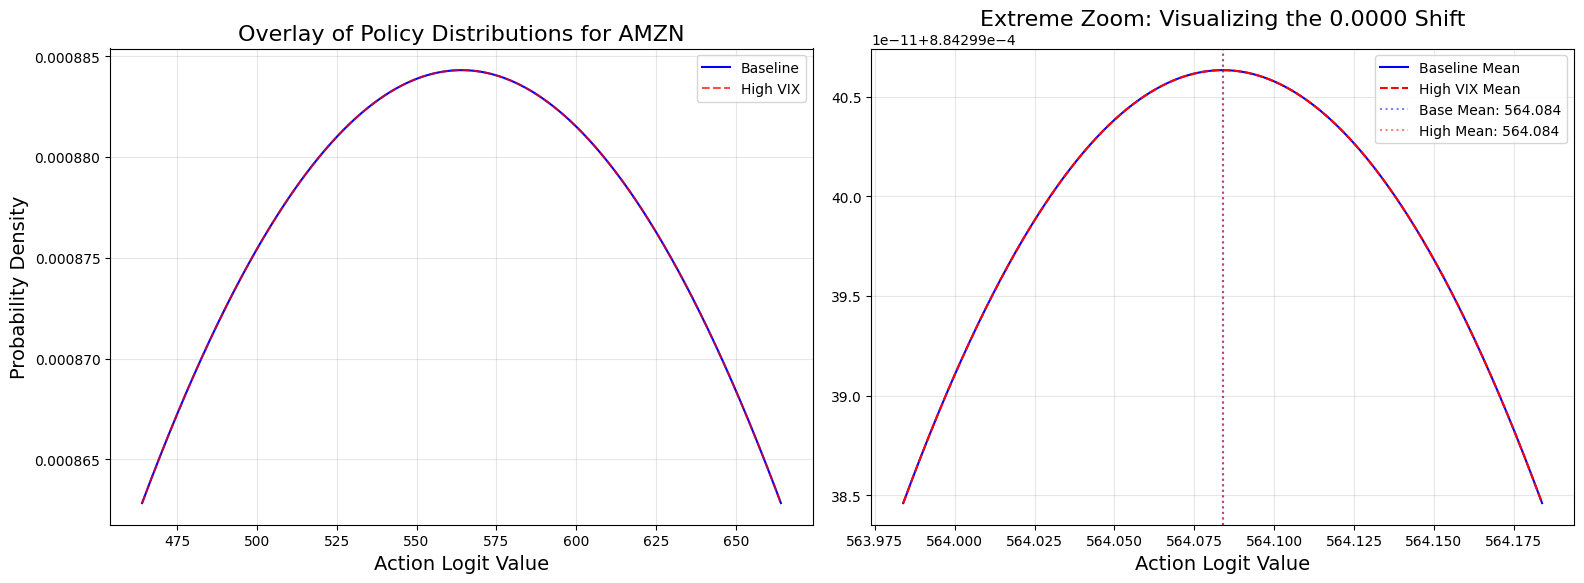


--- Stock: F ---
Baseline: Mean=16.115190505981445, Std=23345832.0
High VIX: Mean=16.115190505981445, Std=23345832.0
Shift: 0.0


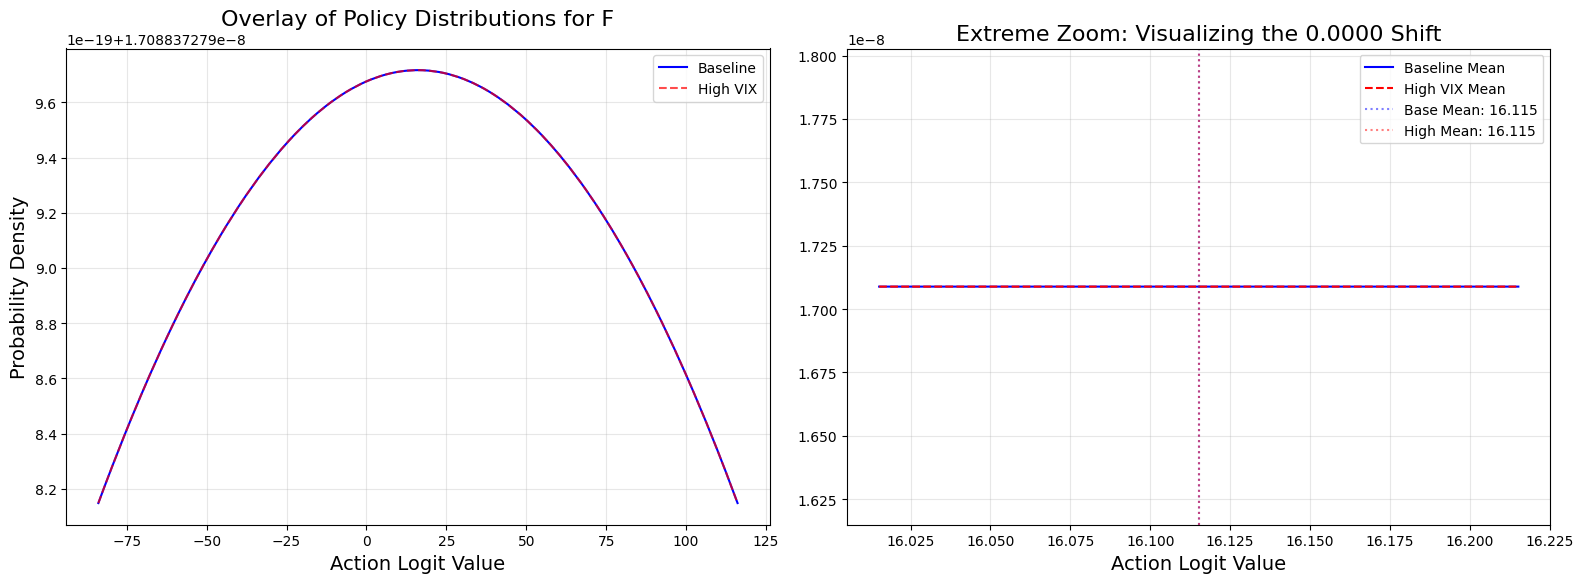


--- Stock: JPM ---
Baseline: Mean=7.863500118255615, Std=28077426.0
High VIX: Mean=7.863500118255615, Std=28077426.0
Shift: 0.0


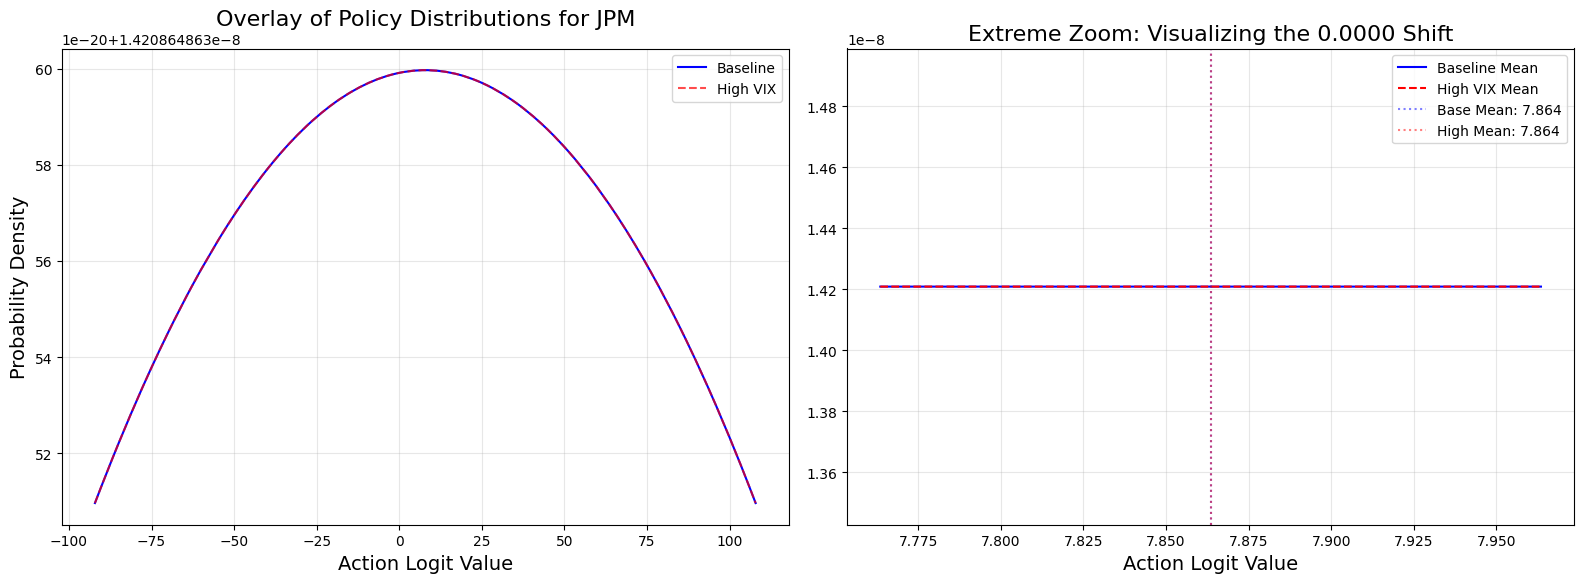


--- Stock: MSFT ---
Baseline: Mean=-15.219940185546875, Std=32824772.0
High VIX: Mean=-15.219940185546875, Std=32824772.0
Shift: 0.0


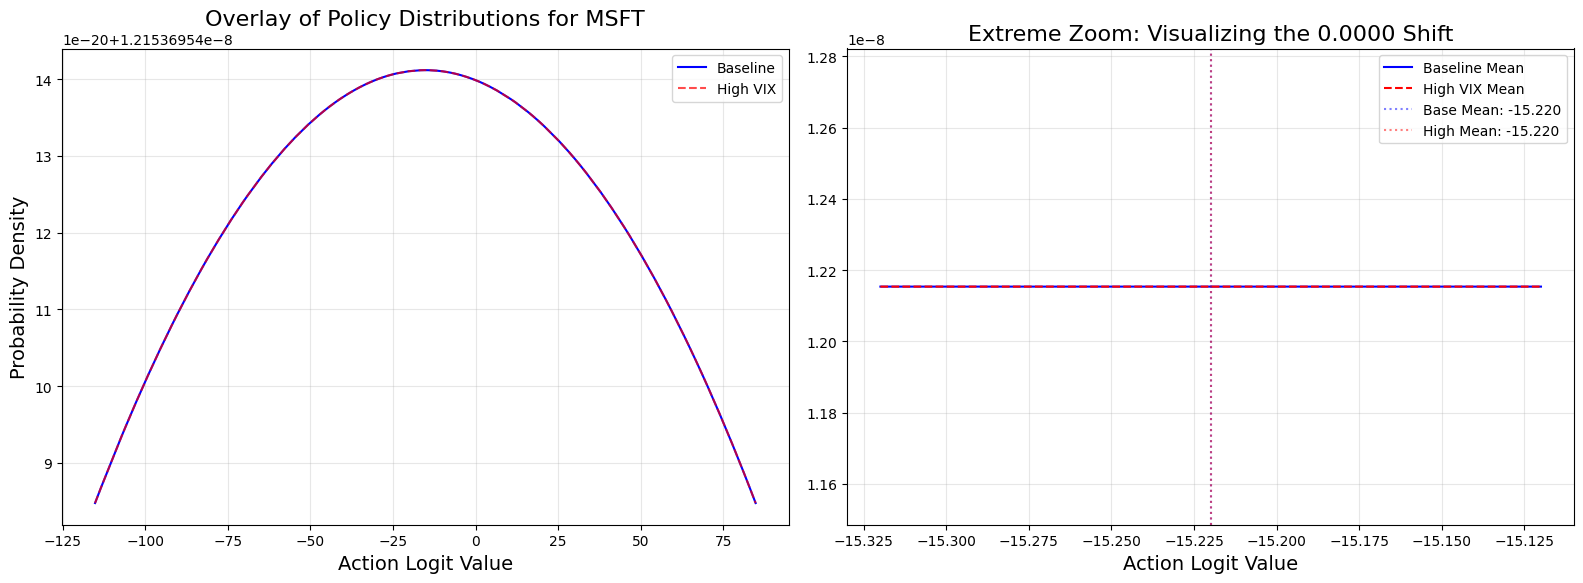


--- Stock: NVDA ---
Baseline: Mean=9.055601119995117, Std=37916508.0
High VIX: Mean=9.055601119995117, Std=37916508.0
Shift: 0.0


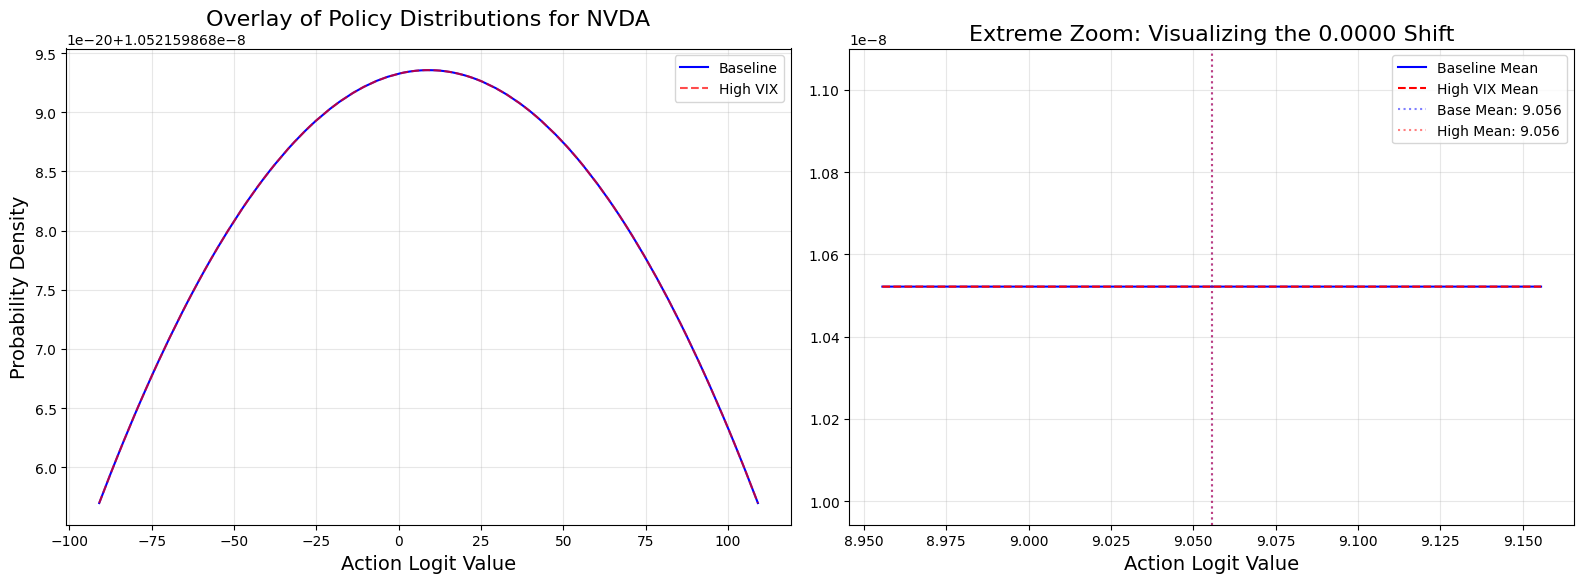


--- Stock: PG ---
Baseline: Mean=-5.162417411804199, Std=37846572.0
High VIX: Mean=-5.162417411804199, Std=37846572.0
Shift: 0.0


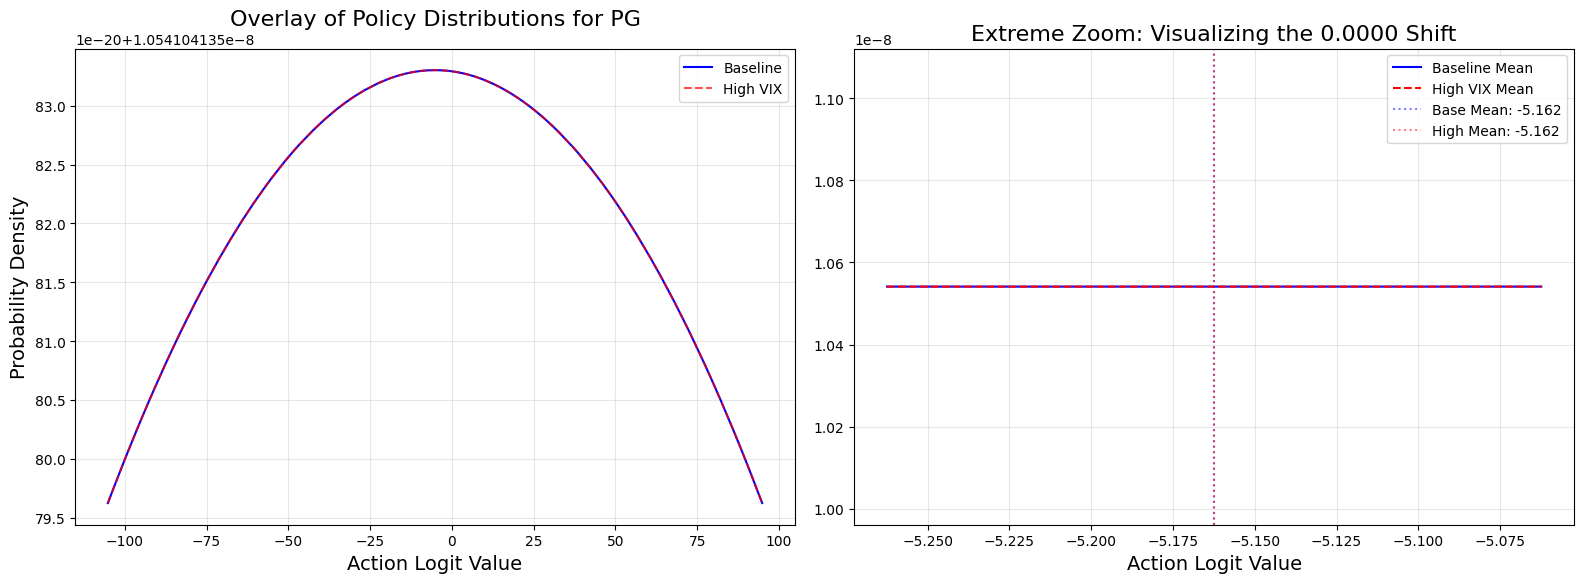


--- Stock: SPY ---
Baseline: Mean=17.52365493774414, Std=37807468.0
High VIX: Mean=17.52365493774414, Std=37807468.0
Shift: 0.0


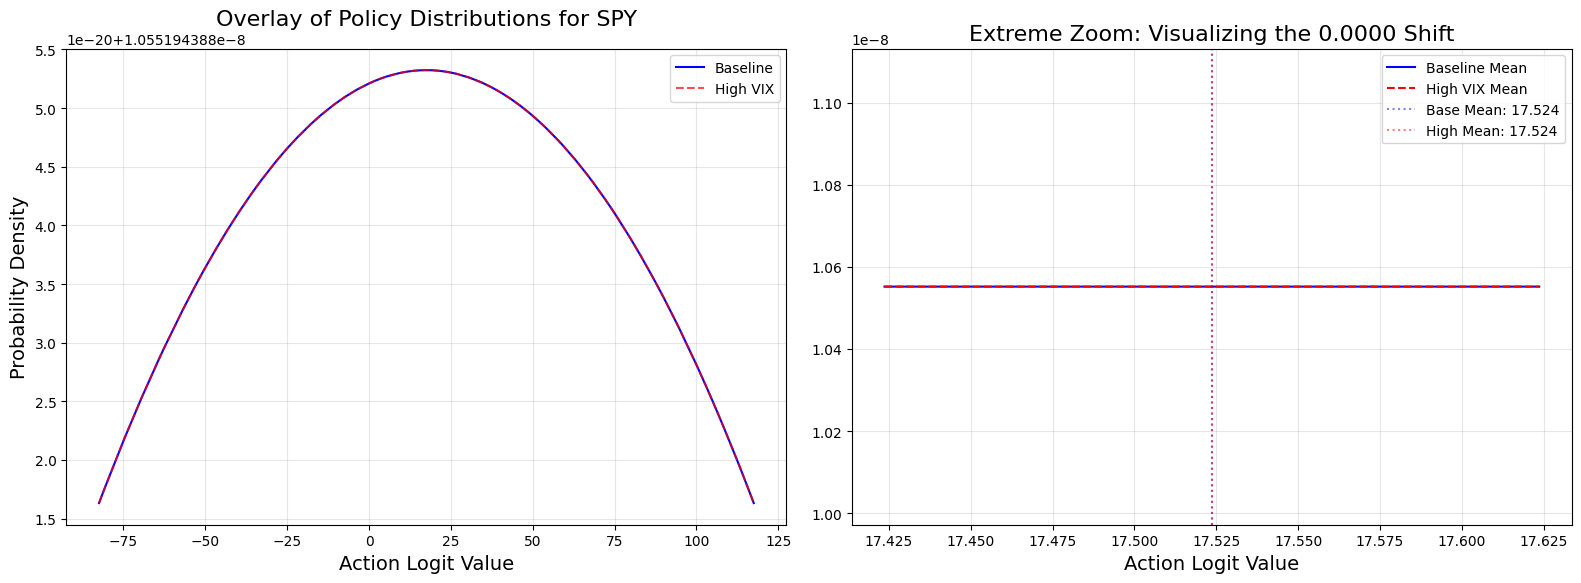


--- Stock: UNH ---
Baseline: Mean=9.111921310424805, Std=28093604.0
High VIX: Mean=9.111921310424805, Std=28093604.0
Shift: 0.0


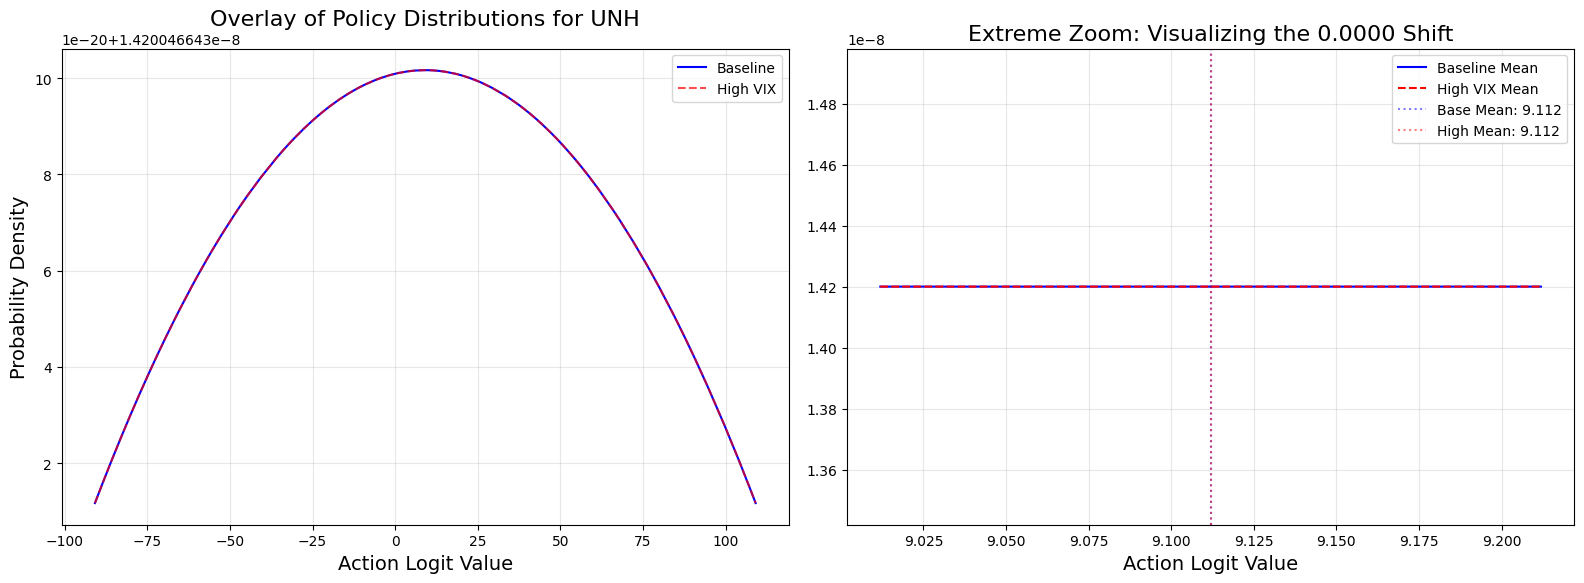


--- Stock: XOM ---
Baseline: Mean=-2.5822198390960693, Std=36037552.0
High VIX: Mean=-2.5822198390960693, Std=36037552.0
Shift: 0.0


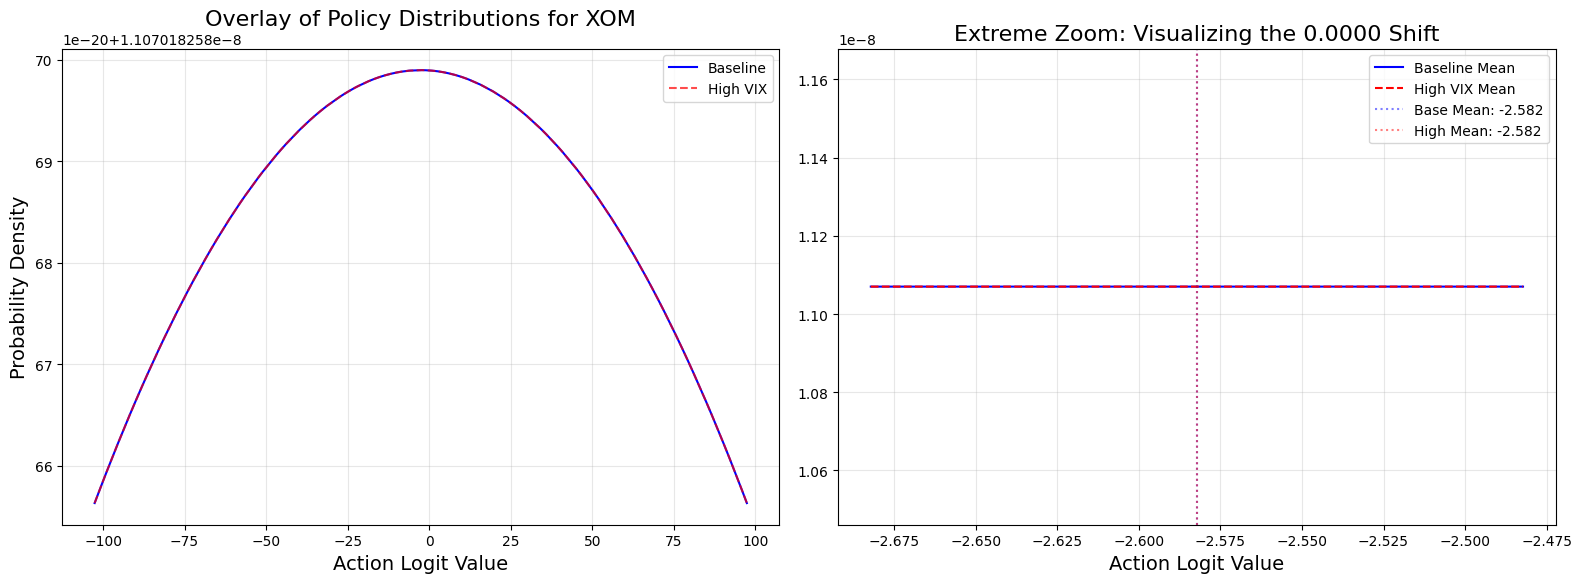

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt

# Loop through all stocks and plot
for i in range(len(sorted_tickers)):
    plot_stock_distribution(i, sorted_tickers, mean_base, std_base, mean_high, std_high)
    plt.show() # Force display of the plot

Average Weight Magnitude across all features: 0.1377
Max Weight Magnitude: 0.1487
VIX Feature (Index 66) Weight Magnitude:    0.1389

CONCLUSION: The model 'sees' the VIX feature, but the saturation in later layers is likely suppressing the reaction.


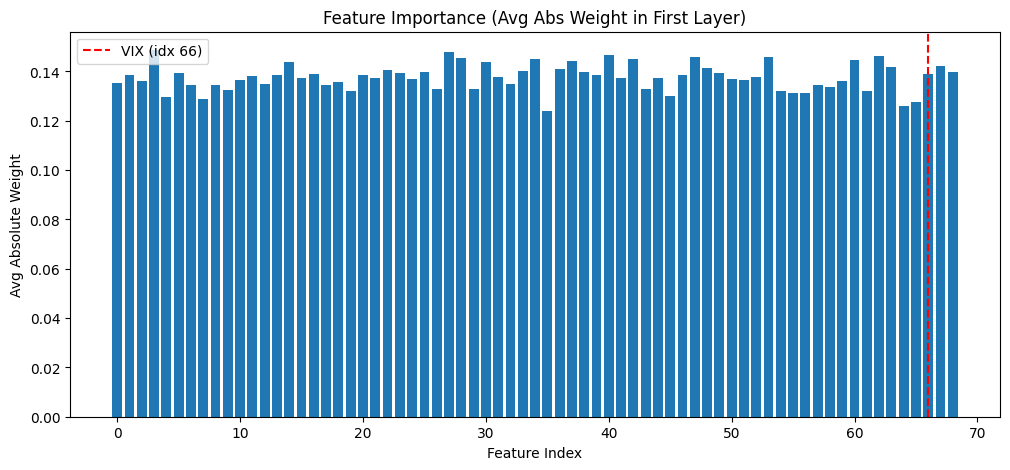

In [31]:
# Access the first linear layer
W = model.policy.features_extractor.mlp.fc1.weight.detach().cpu().numpy()

feature_importance = np.abs(W).mean(axis=0)

# Get VIX importance
vix_importance = feature_importance[66]
avg_importance = feature_importance.mean()
max_importance = feature_importance.max()

print(f"Average Weight Magnitude across all features: {avg_importance:.4f}")
print(f"Max Weight Magnitude: {max_importance:.4f}")
print(f"VIX Feature (Index 66) Weight Magnitude:    {vix_importance:.4f}")

if vix_importance < avg_importance * 0.1:
    print("\nCONCLUSION: The model has effectively 'muted' the VIX feature (weights are very low).")
else:
    print("\nCONCLUSION: The model 'sees' the VIX feature, but the saturation in later layers is likely suppressing the reaction.")

# Plot feature importances
plt.figure(figsize=(12, 5))
plt.bar(range(len(feature_importance)), feature_importance)
plt.axvline(66, color='r', linestyle='--', label='VIX (idx 66)')
plt.title("Feature Importance (Avg Abs Weight in First Layer)")
plt.xlabel("Feature Index")
plt.ylabel("Avg Absolute Weight")
plt.legend()
plt.show()

In [37]:
import copy
import numpy as np

# Define the missing variables
obs_baseline = valid_norm_env.reset()
vix_idx = 66

obs2 = copy.deepcopy(obs_baseline)
# Perturb the VIX feature (index 66) across all time steps
obs2[:, :, vix_idx] += 10.0

a1, _ = model.predict(obs_baseline, deterministic=True)
a2, _ = model.predict(obs2, deterministic=True)

print("max |action diff|:", np.max(np.abs(a2 - a1)))

max |action diff|: 0.0


In [38]:
import torch

obs_b = torch.as_tensor(obs_baseline).float().to(model.device)
obs_h = torch.as_tensor(obs2).float().to(model.device)

with torch.no_grad():
    fb = model.policy.extract_features(obs_b)
    fh = model.policy.extract_features(obs_h)

print("feature max abs diff:", (fh - fb).abs().max().item())

feature max abs diff: 3.970947265625
